# 1 

In [247]:
!ls -lah

total 1680
drwxrwxr-x@ 10 d1sble  staff   320B 16 авг 23:23 .
drwxr-xr-x   4 d1sble  staff   128B 16 авг 21:54 ..
drwxr-xr-x   3 d1sble  staff    96B 16 авг 21:57 .ipynb_checkpoints
-rw-rw-r--@  1 d1sble  staff   5,7K 18 июл  2018 daily-total-female-births-in-cal.csv
-rw-rw-r--@  1 d1sble  staff   2,0K 18 июл  2018 international-airline-passengers.csv
-rw-rw-r--@  1 d1sble  staff   3,5K 18 июл  2018 mean-monthly-air-temperature-deg.csv
-rw-rw-r--@  1 d1sble  staff   1,6K 18 июл  2018 monthly-boston-armed-robberies-j.csv
-rw-rw-r--@  1 d1sble  staff   1,1K 18 июл  2018 monthly-sales-of-company-x-jan-6.csv
-rw-r--r--   1 d1sble  staff   811K 16 авг 23:23 timeque-klimov.ipynb
-rw-rw-r--@  1 d1sble  staff   2,9K 18 июл  2018 weekly-closings-of-the-dowjones-.csv


In [248]:
!pwd

/Users/d1sble/Netology/gitHub/neto_hmrks/timeque/Series


In [249]:
path ="/Users/d1sble/Netology/gitHub/neto_hmrks/timeque/Series"

In [250]:
import pandas as pd

df = pd.read_csv(f'{path}/daily-total-female-births-in-cal.csv', parse_dates=['Date'], index_col='Date')

In [251]:
df.head()

,Count
Date,
1959-01-01,35
1959-01-02,32
1959-01-03,30
1959-01-04,31
1959-01-05,44


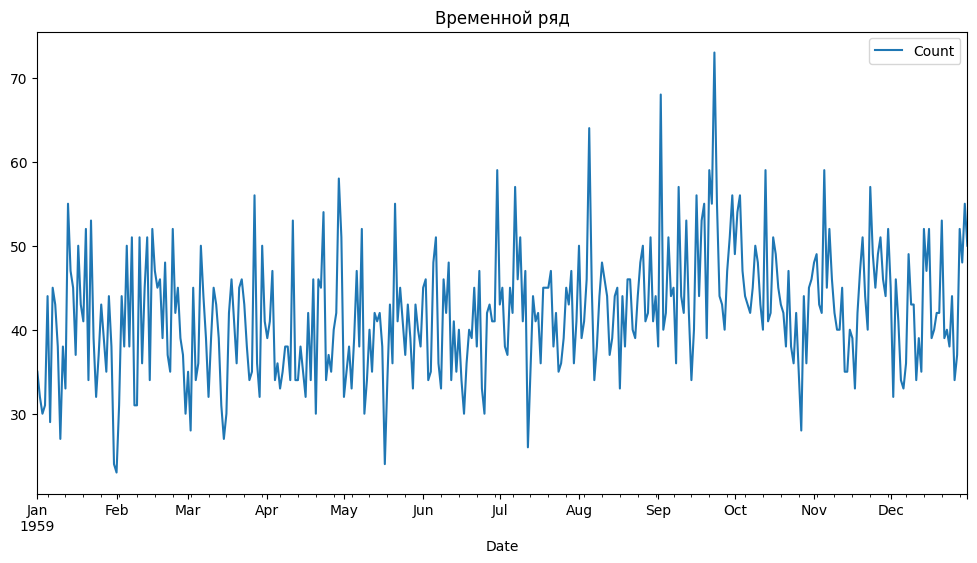

In [252]:
import matplotlib.pyplot as plt

df.plot(figsize=(12, 6), title='Временной ряд')
plt.show()

Смотрим на график

Как такового тренда не видно - критерий стационарности.

Сезонности тоже не выидно - стационарность.

Дисперсия примерно одинаковая на вем рпромежутке.

Проверим критерием Дики - Фулера

In [253]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series):
    result = adfuller(series, autolag='AIC')
    print('ADF Statistic:', result[0])
    print('p-value:', result[1])
    print('Критические значения:')
    for key, value in result[4].items():
        print(f'   {key}: {value}')
    
    if result[1] < 0.05:
        print("Ряд стационарен (отвергаем H0)")
    else:
        print("Ряд нестационарен (не отвергаем H0)")

adf_test(df['Count'])

ADF Statistic: -4.808291253559767
p-value: 5.243412990149787e-05
Критические значения:
   1%: -3.448748905151901
   5%: -2.8696473721448728
   10%: -2.5710891239349585
Ряд стационарен (отвергаем H0)


Нет смысла делать ряд стационарным

# 2

In [254]:
!ls -lah

total 1680
drwxrwxr-x@ 10 d1sble  staff   320B 16 авг 23:23 .
drwxr-xr-x   4 d1sble  staff   128B 16 авг 21:54 ..
drwxr-xr-x   3 d1sble  staff    96B 16 авг 21:57 .ipynb_checkpoints
-rw-rw-r--@  1 d1sble  staff   5,7K 18 июл  2018 daily-total-female-births-in-cal.csv
-rw-rw-r--@  1 d1sble  staff   2,0K 18 июл  2018 international-airline-passengers.csv
-rw-rw-r--@  1 d1sble  staff   3,5K 18 июл  2018 mean-monthly-air-temperature-deg.csv
-rw-rw-r--@  1 d1sble  staff   1,6K 18 июл  2018 monthly-boston-armed-robberies-j.csv
-rw-rw-r--@  1 d1sble  staff   1,1K 18 июл  2018 monthly-sales-of-company-x-jan-6.csv
-rw-r--r--   1 d1sble  staff   811K 16 авг 23:23 timeque-klimov.ipynb
-rw-rw-r--@  1 d1sble  staff   2,9K 18 июл  2018 weekly-closings-of-the-dowjones-.csv


In [255]:

df = pd.read_csv(f'{path}/international-airline-passengers.csv', index_col='Month')

In [256]:
df.head()

,Count
Month,
1949-01,112
1949-02,118
1949-03,132
1949-04,129
1949-05,121


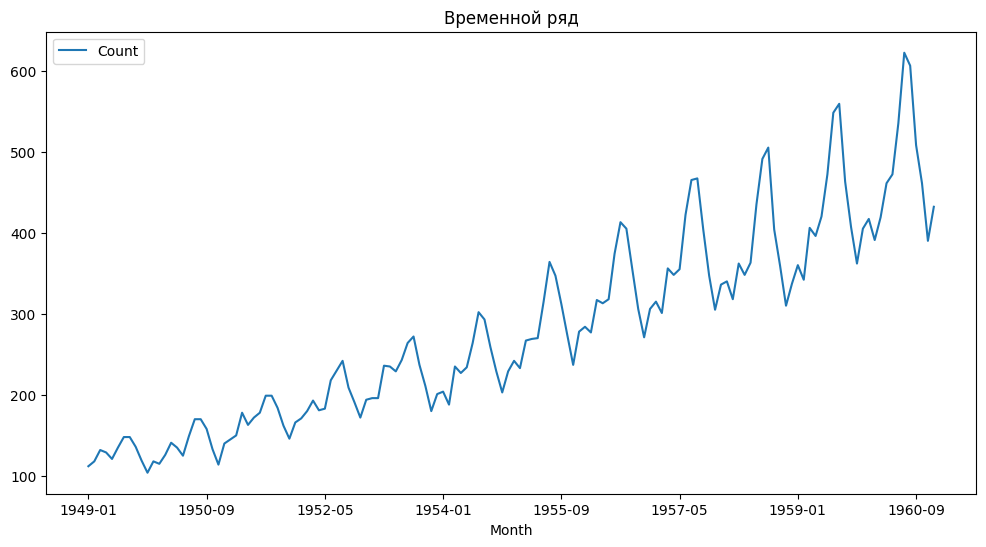

In [257]:
import matplotlib.pyplot as plt

df.plot(figsize=(12, 6), title='Временной ряд')
plt.show()

Смотрим на график

Наблюдаем тренд - критерий нестационарности.

Дисперсия растет

Проверим критерием

In [258]:
adf_test(df['Count'])

ADF Statistic: 0.8153688792060421
p-value: 0.9918802434376409
Критические значения:
   1%: -3.4816817173418295
   5%: -2.8840418343195267
   10%: -2.578770059171598
Ряд нестационарен (не отвергаем H0)


Ну вот такой вот метод работы сразу со всеми тенденциями

In [259]:
values = df['Count']

df['final'] = np.log(values).diff(12).diff(1)

In [260]:
df.dropna(inplace=True)

In [261]:
adf_test(df['final'])

ADF Statistic: -4.443324941831128
p-value: 0.0002485912311383993
Критические значения:
   1%: -3.4870216863700767
   5%: -2.8863625166643136
   10%: -2.580009026141913
Ряд стационарен (отвергаем H0)


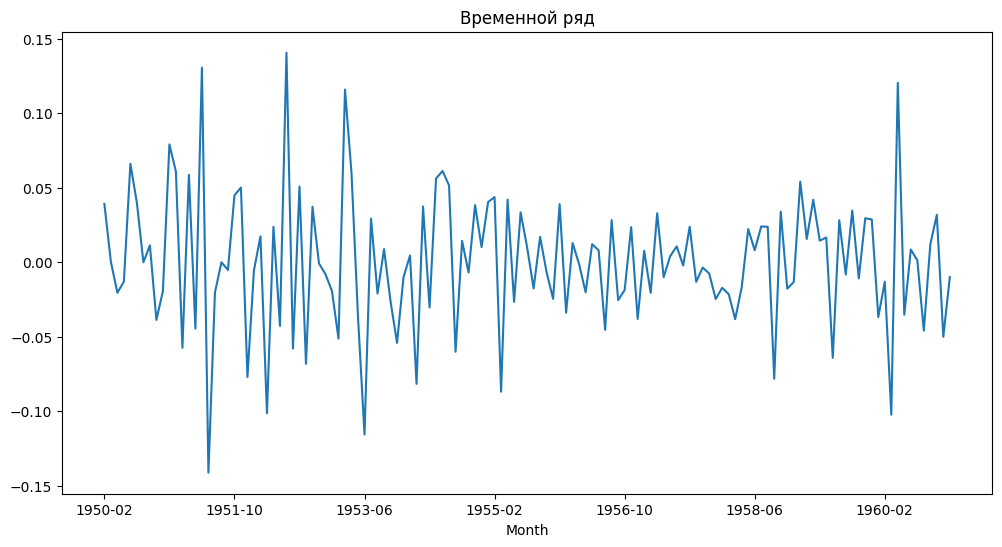

In [262]:
df['final'].plot(figsize=(12, 6), title='Временной ряд')
plt.show()

# 3

In [263]:
!ls -lah


total 1680
drwxrwxr-x@ 10 d1sble  staff   320B 16 авг 23:23 .
drwxr-xr-x   4 d1sble  staff   128B 16 авг 21:54 ..
drwxr-xr-x   3 d1sble  staff    96B 16 авг 21:57 .ipynb_checkpoints
-rw-rw-r--@  1 d1sble  staff   5,7K 18 июл  2018 daily-total-female-births-in-cal.csv
-rw-rw-r--@  1 d1sble  staff   2,0K 18 июл  2018 international-airline-passengers.csv
-rw-rw-r--@  1 d1sble  staff   3,5K 18 июл  2018 mean-monthly-air-temperature-deg.csv
-rw-rw-r--@  1 d1sble  staff   1,6K 18 июл  2018 monthly-boston-armed-robberies-j.csv
-rw-rw-r--@  1 d1sble  staff   1,1K 18 июл  2018 monthly-sales-of-company-x-jan-6.csv
-rw-r--r--   1 d1sble  staff   811K 16 авг 23:23 timeque-klimov.ipynb
-rw-rw-r--@  1 d1sble  staff   2,9K 18 июл  2018 weekly-closings-of-the-dowjones-.csv


In [264]:

df = pd.read_csv(f'{path}/mean-monthly-air-temperature-deg.csv', index_col='Month')
df.head()

,Deg
Month,
1920-01,40.6
1920-02,40.8
1920-03,44.4
1920-04,46.7
1920-05,54.1


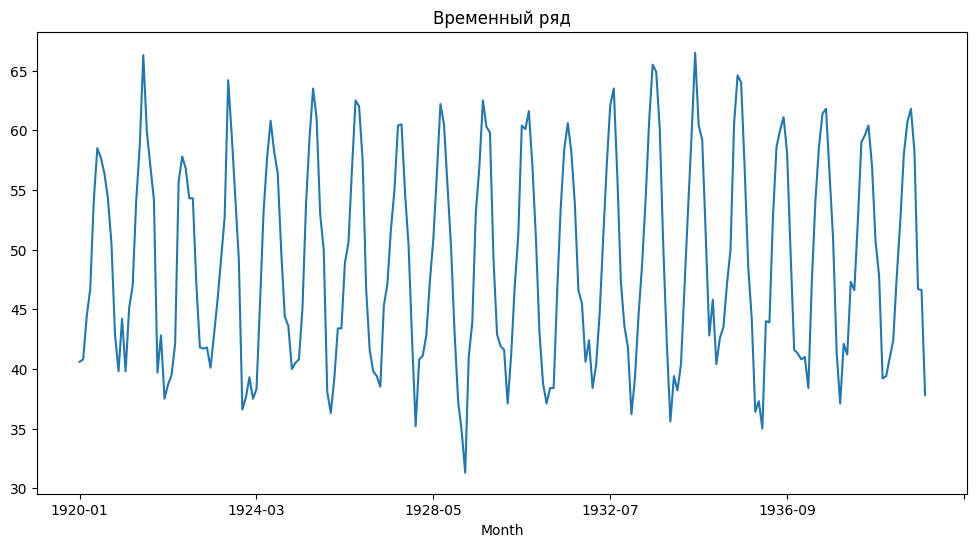

In [265]:
df.Deg.plot(figsize=(12,6), title='Временный ряд')
plt.show()

Выглядит стационарным

In [266]:
adf_test(df.Deg)

ADF Statistic: -3.2554924030863472
p-value: 0.01698903022260808
Критические значения:
   1%: -3.4597521044060353
   5%: -2.874472927517147
   10%: -2.5736628197530864
Ряд стационарен (отвергаем H0)


# 4

In [267]:
!ls -lah

total 1680
drwxrwxr-x@ 10 d1sble  staff   320B 16 авг 23:23 .
drwxr-xr-x   4 d1sble  staff   128B 16 авг 21:54 ..
drwxr-xr-x   3 d1sble  staff    96B 16 авг 21:57 .ipynb_checkpoints
-rw-rw-r--@  1 d1sble  staff   5,7K 18 июл  2018 daily-total-female-births-in-cal.csv
-rw-rw-r--@  1 d1sble  staff   2,0K 18 июл  2018 international-airline-passengers.csv
-rw-rw-r--@  1 d1sble  staff   3,5K 18 июл  2018 mean-monthly-air-temperature-deg.csv
-rw-rw-r--@  1 d1sble  staff   1,6K 18 июл  2018 monthly-boston-armed-robberies-j.csv
-rw-rw-r--@  1 d1sble  staff   1,1K 18 июл  2018 monthly-sales-of-company-x-jan-6.csv
-rw-r--r--   1 d1sble  staff   811K 16 авг 23:23 timeque-klimov.ipynb
-rw-rw-r--@  1 d1sble  staff   2,9K 18 июл  2018 weekly-closings-of-the-dowjones-.csv


In [268]:

df = pd.read_csv(f'{path}/monthly-boston-armed-robberies-j.csv', index_col='Month')
df.head()

,Count
Month,
1966-01,41
1966-02,39
1966-03,50
1966-04,40
1966-05,43


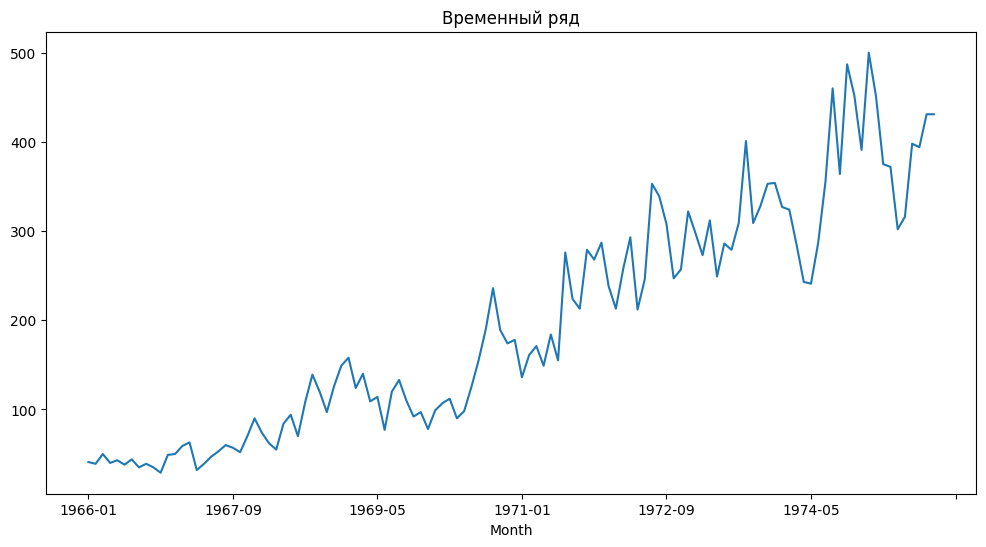

In [269]:
df.Count.plot(figsize=(12,6), title='Временный ряд')
plt.show()

Видим тренд и я предположу, что ряд сезонный и дисперсия точно растет. Не буду изобретать велосипед

In [270]:
adf_test(df['Count'])

ADF Statistic: 1.0011021402457965
p-value: 0.9942775638057232
Критические значения:
   1%: -3.4936021509366793
   5%: -2.8892174239808703
   10%: -2.58153320754717
Ряд нестационарен (не отвергаем H0)


In [271]:
values = df['Count']

df['final'] = np.log(values).diff(12).diff(1)

In [272]:
adf_test(df['final'].dropna())

ADF Statistic: -4.232983671661597
p-value: 0.0005791258821324162
Критические значения:
   1%: -3.50434289821397
   5%: -2.8938659630479413
   10%: -2.5840147047458037
Ряд стационарен (отвергаем H0)


# 5

In [273]:
! ls -lah

total 1680
drwxrwxr-x@ 10 d1sble  staff   320B 16 авг 23:23 .
drwxr-xr-x   4 d1sble  staff   128B 16 авг 21:54 ..
drwxr-xr-x   3 d1sble  staff    96B 16 авг 21:57 .ipynb_checkpoints
-rw-rw-r--@  1 d1sble  staff   5,7K 18 июл  2018 daily-total-female-births-in-cal.csv
-rw-rw-r--@  1 d1sble  staff   2,0K 18 июл  2018 international-airline-passengers.csv
-rw-rw-r--@  1 d1sble  staff   3,5K 18 июл  2018 mean-monthly-air-temperature-deg.csv
-rw-rw-r--@  1 d1sble  staff   1,6K 18 июл  2018 monthly-boston-armed-robberies-j.csv
-rw-rw-r--@  1 d1sble  staff   1,1K 18 июл  2018 monthly-sales-of-company-x-jan-6.csv
-rw-r--r--   1 d1sble  staff   811K 16 авг 23:23 timeque-klimov.ipynb
-rw-rw-r--@  1 d1sble  staff   2,9K 18 июл  2018 weekly-closings-of-the-dowjones-.csv


In [274]:
df = pd.read_csv(f'{path}/monthly-sales-of-company-x-jan-6.csv', index_col='Month', parse_dates=['Month'])
df.head()

,Count
Month,
1965-01-01,154
1965-02-01,96
1965-03-01,73
1965-04-01,49
1965-05-01,36


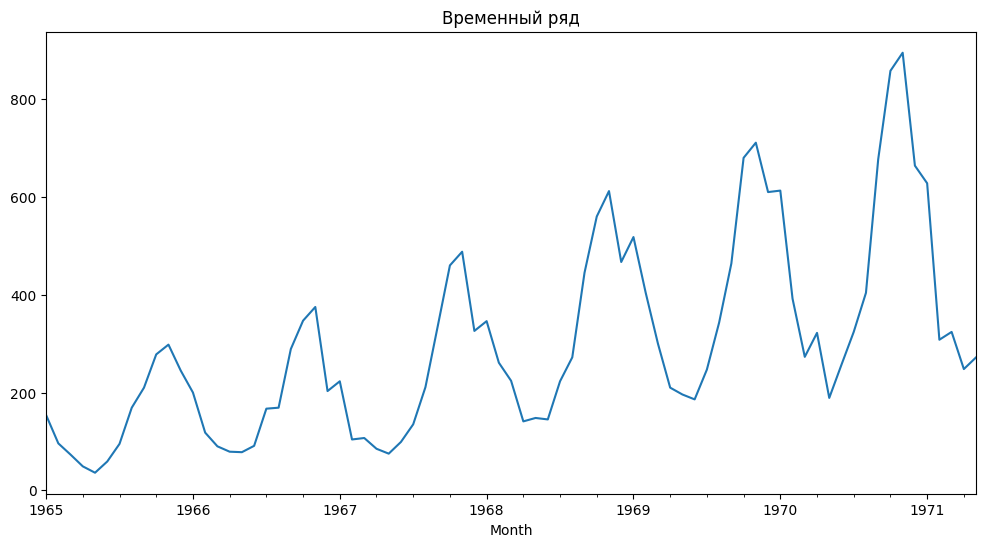

In [275]:
df.Count.plot(figsize=(12,6), title='Временный ряд')
#plt.xticks(np.arange(1,6))
plt.show()

Видно что имеются пики преимущественно в ноябре, а это признак сезонности. Ко всему прочему имеем тренд и гетероскедантичность

In [276]:
adf_test(df.Count)

ADF Statistic: 0.6547150829524464
p-value: 0.9888894205170052
Критические значения:
   1%: -3.53692771987915
   5%: -2.907887369384766
   10%: -2.591493291015625
Ряд нестационарен (не отвергаем H0)


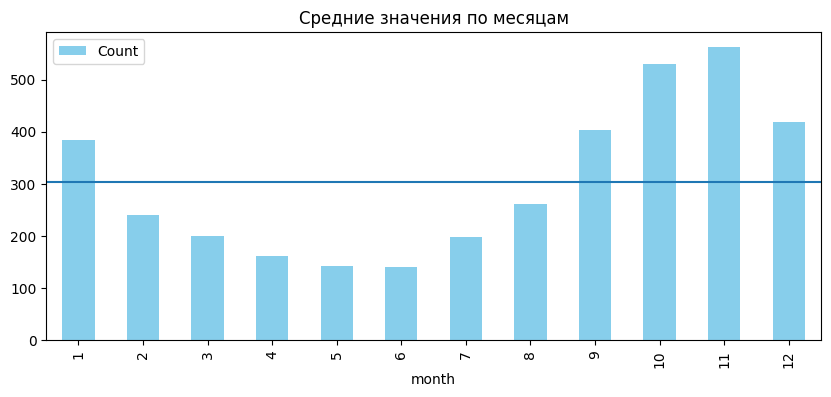

In [277]:

df['month'] = df.index.month  
monthly_peaks = df.groupby('month')['Count'].mean()
plt.figure(figsize=(10, 4))
monthly_peaks.plot(kind='bar', color='skyblue')
plt.axhline(y=monthly_peaks.mean())
plt.title('Средние значения по месяцам')
plt.legend()
plt.show()

Ну как минимум не в ноябре, но зимой

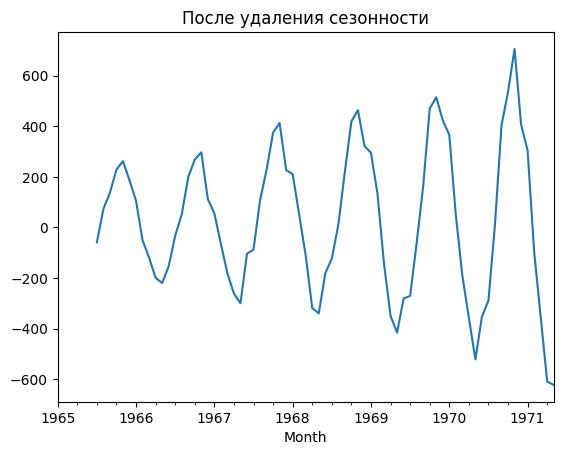

In [278]:
df['deseasonalized'] = df['Count'].diff(6).dropna()

# Проверяем результат
df['deseasonalized'].plot(title='После удаления сезонности')
plt.show()

In [279]:
shift = abs(df['deseasonalized'].min()) + 1 
df['corrected'] = df['deseasonalized'] + shift

In [280]:
df.dropna(inplace=True)

In [281]:
from scipy.stats import boxcox
df['boxcox'], lambda_ = boxcox(df['corrected'] + 1) 
print(f"Оптимальный lambda: {lambda_:.2f}")

Оптимальный lambda: 0.85


In [282]:
values = df['boxcox']
df['final'] = np.log(values).diff(1).diff(1)

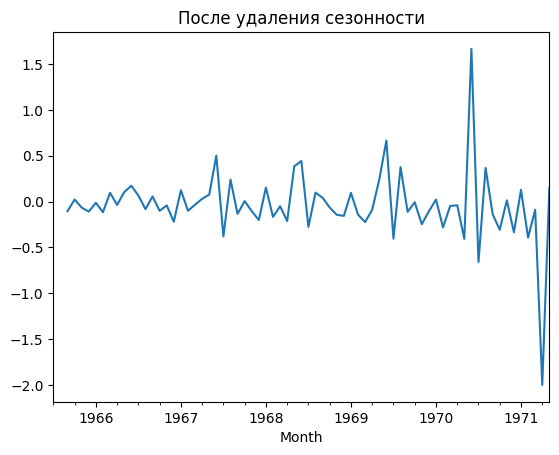

In [283]:
df['final'].plot(title='После удаления сезонности')
plt.show()

In [284]:
adf_test(df.final.dropna())

ADF Statistic: -7.43118373782687
p-value: 6.354540233594122e-11
Критические значения:
   1%: -3.548493559596539
   5%: -2.912836594776334
   10%: -2.594129155766944
Ряд стационарен (отвергаем H0)


# 6 

In [285]:
!ls -lah

total 1680
drwxrwxr-x@ 10 d1sble  staff   320B 16 авг 23:23 .
drwxr-xr-x   4 d1sble  staff   128B 16 авг 21:54 ..
drwxr-xr-x   3 d1sble  staff    96B 16 авг 21:57 .ipynb_checkpoints
-rw-rw-r--@  1 d1sble  staff   5,7K 18 июл  2018 daily-total-female-births-in-cal.csv
-rw-rw-r--@  1 d1sble  staff   2,0K 18 июл  2018 international-airline-passengers.csv
-rw-rw-r--@  1 d1sble  staff   3,5K 18 июл  2018 mean-monthly-air-temperature-deg.csv
-rw-rw-r--@  1 d1sble  staff   1,6K 18 июл  2018 monthly-boston-armed-robberies-j.csv
-rw-rw-r--@  1 d1sble  staff   1,1K 18 июл  2018 monthly-sales-of-company-x-jan-6.csv
-rw-r--r--   1 d1sble  staff   811K 16 авг 23:23 timeque-klimov.ipynb
-rw-rw-r--@  1 d1sble  staff   2,9K 18 июл  2018 weekly-closings-of-the-dowjones-.csv


In [286]:
df = pd.read_csv(f'{path}/weekly-closings-of-the-dowjones-.csv', index_col='Week', parse_dates=['Week'])
df.head()

/var/folders/xv/zrplmy153n904sqktkc05fd40000gn/T/ipykernel_8293/3360751682.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(f'{path}/weekly-closings-of-the-dowjones-.csv', index_col='Week', parse_dates=['Week'])


,Close
Week,
1971-W27,890.19
1971-W28,901.80
1971-W29,888.51
1971-W30,887.78
1971-W31,858.43


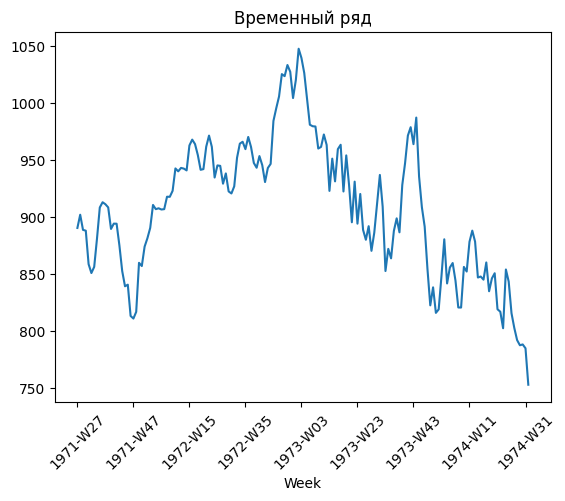

In [287]:
df['Close'].plot(title='Временный ряд')
plt.xticks(rotation=45)
plt.show()

Ни рыба ни мясо как говорится

In [288]:
adf_test(df.Close)

ADF Statistic: -1.3146254984911765
p-value: 0.6224548515589696
Критические значения:
   1%: -3.471633386932248
   5%: -2.8796651107461972
   10%: -2.576433647235832
Ряд нестационарен (не отвергаем H0)


Логарифмирование всегда работает

In [289]:
values = df['Close']

df['final'] = np.log(values).diff(1).diff(1)

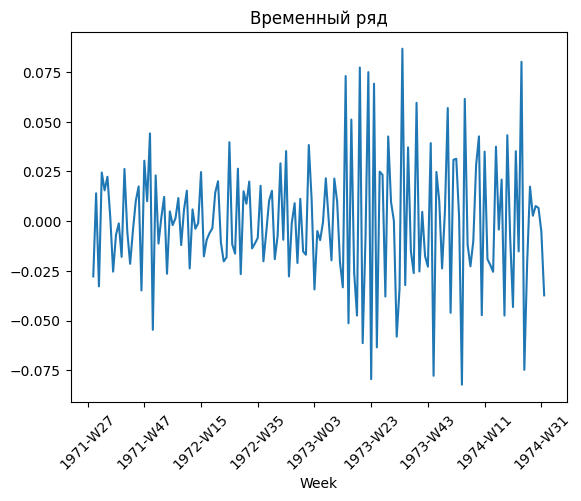

In [290]:
df['final'].plot(title='Временный ряд')
plt.xticks(rotation=45)
plt.show()

In [291]:
adf_test(df.final.dropna())

ADF Statistic: -5.0993778171722735
p-value: 1.4059436083698205e-05
Критические значения:
   1%: -3.476273058920005
   5%: -2.881687616548444
   10%: -2.5775132580261593
Ряд стационарен (отвергаем H0)
